4-Class Temporal Waveform Classification

Classifies four glucose-dosing waveforms (rising ramp A, falling ramp B, pulse pair C, Mackey motif D) from 13 reservoir sensor channels.
Trial sequence run: `A, C, B, D, B, A, D, C, D, B, C, A` — 12 trials × 6 stimulus cycles × 6 min ≈ 12 hours.

Pipeline: cycle-level feature aggregation → delay embedding → RidgeClassifierCV with TimeSeriesSplit → verification controls.

In [23]:
from __future__ import annotations

from pathlib import Path
import json
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifierCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 160

DATA_DIR = Path(r"28th May/")        
OUT_DIR  = Path(r"./outputs/mg_28may_4class")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Experiment parameters ─────────────────────────────────────────────
CYCLE_MIN        = 6.0
STIMULUS_CYCLES  = 6
RESPONSE_CYCLES  = 2
WASHOUT_CYCLES   = 2
CYCLES_PER_TRIAL = STIMULUS_CYCLES + RESPONSE_CYCLES + WASHOUT_CYCLES  # 10

TRIAL_SEQUENCE = list('ACBDBADCDBCA')   # 12 trials

CLASS_MOTIFS = {
    'A': [0.05, 0.08, 0.12, 0.16, 0.21, 0.25],   # rising ramp
    'B': [0.25, 0.21, 0.16, 0.12, 0.08, 0.05],   # falling ramp
    'C': [0.05, 0.22, 0.05, 0.05, 0.22, 0.05],   # pulse pair
    'D': [0.06, 0.05, 0.08, 0.14, 0.22, 0.25],   # mackey motif
}

CLASS_COLORS = {'A': '#378ADD', 'B': '#1D9E75', 'C': '#D4537E', 'D': '#BA7517'}

ALPHAS      = np.logspace(-4, 4, 17)
RANDOM_SEED = 42


In [24]:
# Load the raw 28 May exports.

def load_csv(name: str) -> pd.DataFrame:
    df = pd.read_csv(DATA_DIR / name)
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
    if 'timestamp_localtime' in df.columns:
        df['timestamp_localtime'] = pd.to_datetime(df['timestamp_localtime'], errors='coerce')
    return df

SUFFIX = '20260528134818'
od_raw  = load_csv(f'od_readings-Experiment_002-all_units-{SUFFIX}.csv')
od_filt = load_csv(f'od_readings_filtered-Experiment_002-all_units-{SUFFIX}.csv')
growth  = load_csv(f'growth_rates-Experiment_002-all_units-{SUFFIX}.csv')
spec    = load_csv(f'as7341_spectrum_readings-Experiment_002-all_units-{SUFFIX}.csv')
dosing  = load_csv(f'dosing_events-Experiment_002-all_units-{SUFFIX}.csv')
temp    = load_csv(f'temperature_readings-Experiment_002-all_units-{SUFFIX}.csv')

print('Rows:')
for name, df in [('od_raw', od_raw), ('od_filt', od_filt), ('growth', growth),
                 ('spec', spec), ('dosing', dosing), ('temp', temp)]:
    print(f'{name:8s}: {len(df):6d}')

print('\nDosing event counts:')
print(dosing['event'].value_counts(dropna=False).to_string())


Rows:
od_raw  :  25704
od_filt :   8274
growth  :   8274
spec    :  68520
dosing  :    303
temp    :    217

Dosing event counts:
event
add_media       159
remove_waste    144


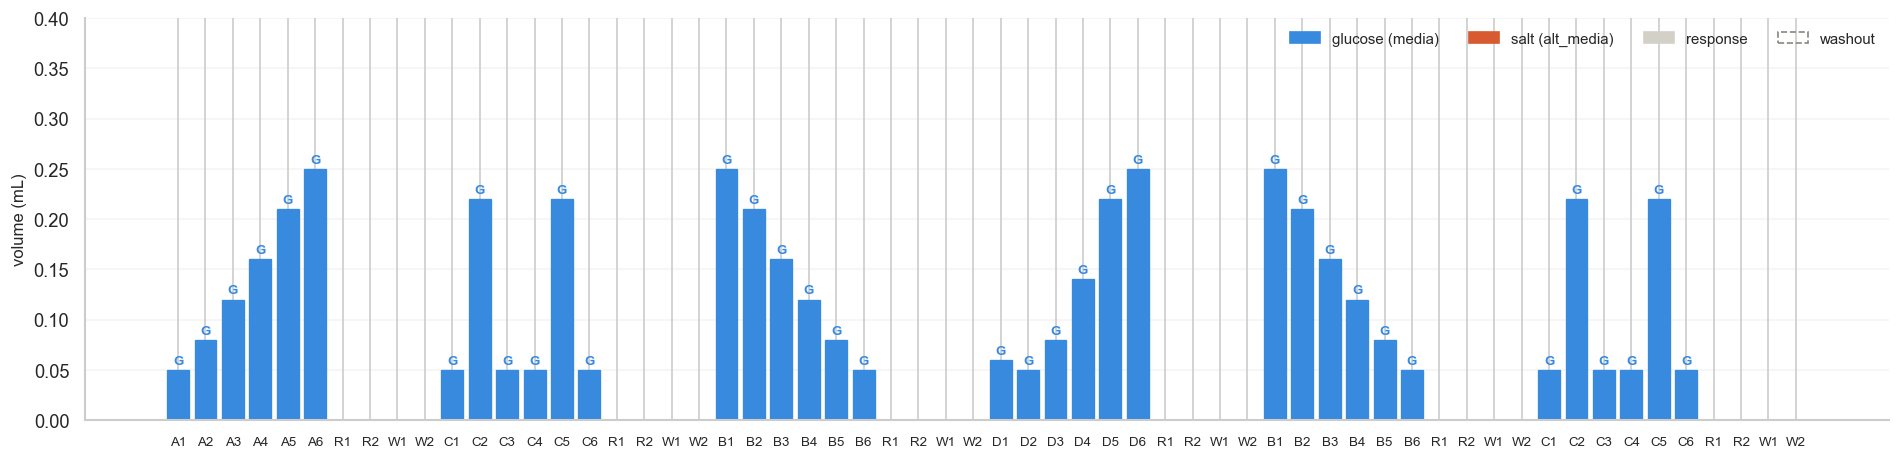

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# CLASS_LIBRARY = {
#     "A": [("media", 0.08), ("media", 0.08), ("alt_media", 0.08), ("alt_media", 0.08)],
#     "B": [("media", 0.08), ("alt_media", 0.08), ("media", 0.08), ("alt_media", 0.08)],
#     "C": [("alt_media", 0.08), ("alt_media", 0.08), ("media", 0.08), ("media", 0.08)],
# }

CLASS_LIBRARY = {
    # Rising ramp — slow start, accelerating glucose feed
    "A": [
        ("media", 0.05),
        ("media", 0.08),
        ("media", 0.12),
        ("media", 0.16),
        ("media", 0.21),
        ("media", 0.25),
    ],
    # Falling ramp — heavy front-load, tapering off
    "B": [
        ("media", 0.25),
        ("media", 0.21),
        ("media", 0.16),
        ("media", 0.12),
        ("media", 0.08),
        ("media", 0.05),
    ],
    # Pulse pair — two sharp spikes with low baseline
    "C": [
        ("media", 0.05),
        ("media", 0.22),
        ("media", 0.05),
        ("media", 0.05),
        ("media", 0.22),
        ("media", 0.05),
    ],
    # Mackey-Glass motif — flat then nonlinear surge
    "D": [
        ("media", 0.06),
        ("media", 0.05),
        ("media", 0.08),
        ("media", 0.14),
        ("media", 0.22),
        ("media", 0.25),
    ],
}

PUMP_COLOR = {"media": "#378ADD", "alt_media": "#D85A30"}
PUMP_LABEL = {"media": "G", "alt_media": "S"}
CLASS_COLORS = {"A": "#534AB7", "B": "#1D9E75", "C": "#BA7517"}
RESPONSE_CYCLES = 2
WASHOUT_CYCLES  = 2

sequence = ["A", "C", "B", "D", "B", "C"]   # match your pio run command

volumes, bar_colors, edge_colors, tick_labels, pump_types = [], [], [], [], []

for cls in sequence:
    for i, (pump, vol) in enumerate(CLASS_LIBRARY[cls]):
        volumes.append(vol)
        bar_colors.append(PUMP_COLOR[pump])
        edge_colors.append(PUMP_COLOR[pump])
        tick_labels.append(f"{cls}{i+1}")
        pump_types.append(pump)
    for i in range(RESPONSE_CYCLES):
        volumes.append(0)
        bar_colors.append("#D3D1C7")
        edge_colors.append("#B4B2A9")
        tick_labels.append(f"R{i+1}")
        pump_types.append("none")
    for i in range(WASHOUT_CYCLES):
        volumes.append(0)
        bar_colors.append("none")
        edge_colors.append("#888780")
        tick_labels.append(f"W{i+1}")
        pump_types.append("none")

fig, ax = plt.subplots(figsize=(16, 4))

bars = ax.bar(range(len(volumes)), volumes, color=bar_colors,
              edgecolor=edge_colors, linewidth=0.8)

# dashed border for washout
for bar, pump in zip(bars, pump_types):
    if pump == "none" and bar.get_facecolor()[3] == 0:  # transparent = washout
        bar.set_linestyle("--")

# G / S labels on stimulus bars
for bar, pump in zip(bars, pump_types):
    if pump in ("media", "alt_media"):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                PUMP_LABEL[pump],
                ha="center", va="bottom", fontsize=8,
                color=PUMP_COLOR[pump], fontweight="bold")

ax.set_xticks(range(len(tick_labels)))
ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_ylabel("volume (mL)", fontsize=10)
ax.set_ylim(0, 0.40)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)

legend = [
    mpatches.Patch(color="#378ADD", label="glucose (media)"),
    mpatches.Patch(color="#D85A30", label="salt (alt_media)"),
    mpatches.Patch(color="#D3D1C7", label="response"),
    mpatches.Patch(facecolor="none", edgecolor="#888780", linestyle="--", label="washout"),
]
ax.legend(handles=legend, fontsize=9, frameon=False, ncol=4, loc="upper right")

plt.tight_layout()
plt.savefig("trial_sequence_classes.png", dpi=150)
plt.show()

### Reconstruct the cycle timeline

The automation runs on 6-minute cycles. This cell bins the raw sensor streams into those cycles, and derives the observed stimulus identity from the dosing log.

In [27]:
# Reconstruct cycle-level features using 6-minute bins from the first dosing event.
# Label each stimulus cycle with its parent trial's motif class (A/B/C/D).

run_start = dosing['timestamp'].min()
run_end   = max([
    dosing['timestamp'].max(), od_raw['timestamp'].max(),
    od_filt['timestamp'].max(), growth['timestamp'].max(),
    spec['timestamp'].max(), temp['timestamp'].max(),
])

cycle_seconds = int(CYCLE_MIN * 60)

def add_cycle_index(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out[out['timestamp'].notna()].copy()
    out['cycle_idx'] = (
        (out['timestamp'] - run_start).dt.total_seconds() // cycle_seconds
    ).astype('Int64')
    return out[out['cycle_idx'] >= 0].copy()

od_raw_c  = add_cycle_index(od_raw)
od_filt_c = add_cycle_index(od_filt)
growth_c  = add_cycle_index(growth)
spec_c    = add_cycle_index(spec)
temp_c    = add_cycle_index(temp)
dosing_c  = add_cycle_index(dosing)

# Aggregate sensor streams to one row per cycle.
od_cycle = (
    od_raw_c.pivot_table(index='cycle_idx', columns='angle', values='od_reading', aggfunc='last')
    .rename(columns={45: 'OD_45', 90: 'OD_90', 135: 'OD_135'})
)
odf_cycle  = od_filt_c.sort_values('timestamp').groupby('cycle_idx')['normalized_od_reading'].last().rename('norm_od')
gr_cycle   = growth_c.sort_values('timestamp').groupby('cycle_idx')['rate'].last().rename('growth_rate')
spec_cycle = (
    spec_c.pivot_table(index='cycle_idx', columns='band', values='reading', aggfunc='last')
    .rename(columns={415:'nm_415',445:'nm_445',480:'nm_480',515:'nm_515',
                     555:'nm_555',590:'nm_590',630:'nm_630',680:'nm_680'})
)

cycle_df = od_cycle.join([odf_cycle, gr_cycle, spec_cycle], how='outer')
cycle_df.index.name = 'cycle_idx'
cycle_df['cycle_start'] = run_start + pd.to_timedelta(cycle_df.index.astype(float) * CYCLE_MIN, unit='m')
cycle_df['cycle_end']   = cycle_df['cycle_start'] + pd.to_timedelta(CYCLE_MIN, unit='m')

# ── Assign motif class label to each stimulus cycle ───────────────────
# Group add_media bursts (events within 10s = one dosing action) → ordered list of stimulus cycles
media_ev = dosing_c[dosing_c['event'] == 'add_media'].sort_values('timestamp').copy()
media_ev['burst_group'] = (media_ev['timestamp'].diff().dt.total_seconds() > 10).cumsum()
cycle_bursts = (
    media_ev.groupby('burst_group')
    .agg(cycle_idx=('cycle_idx', 'first'))
    .reset_index(drop=True)
)
# Every STIMULUS_CYCLES consecutive burst groups = one trial
cycle_bursts['trial_idx']   = cycle_bursts.index // STIMULUS_CYCLES
cycle_bursts['motif_class'] = cycle_bursts['trial_idx'].apply(
    lambda i: TRIAL_SEQUENCE[i] if i < len(TRIAL_SEQUENCE) else 'unknown'
)
cycle_to_class = cycle_bursts.set_index('cycle_idx')['motif_class']
cycle_df['motif_class'] = cycle_df.index.map(cycle_to_class).fillna('none')

feature_cols = [
    'OD_45', 'OD_90', 'OD_135',
    'norm_od', 'growth_rate',
    'nm_415', 'nm_445', 'nm_480', 'nm_515', 'nm_555', 'nm_590', 'nm_630', 'nm_680',
]

print('Cycle rows :', len(cycle_df))
print('Class counts:\n', cycle_df['motif_class'].value_counts().to_string())
print('\nStimulus cycle sequence (class per cycle):')
print(cycle_df.loc[cycle_df['motif_class'] != 'none', 'motif_class'].tolist())


Cycle rows : 119
Class counts:
 motif_class
none    47
A       18
C       18
B       18
D       18

Stimulus cycle sequence (class per cycle):
['A', 'A', 'A', 'A', 'A', 'A', 'C', 'C', 'C', 'C', 'C', 'C', 'B', 'B', 'B', 'B', 'B', 'B', 'D', 'D', 'D', 'D', 'D', 'D', 'B', 'B', 'B', 'B', 'B', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'D', 'D', 'D', 'D', 'D', 'D', 'C', 'C', 'C', 'C', 'C', 'C', 'D', 'D', 'D', 'D', 'D', 'D', 'B', 'B', 'B', 'B', 'B', 'B', 'C', 'C', 'C', 'C', 'C', 'C', 'A', 'A', 'A', 'A', 'A', 'A']


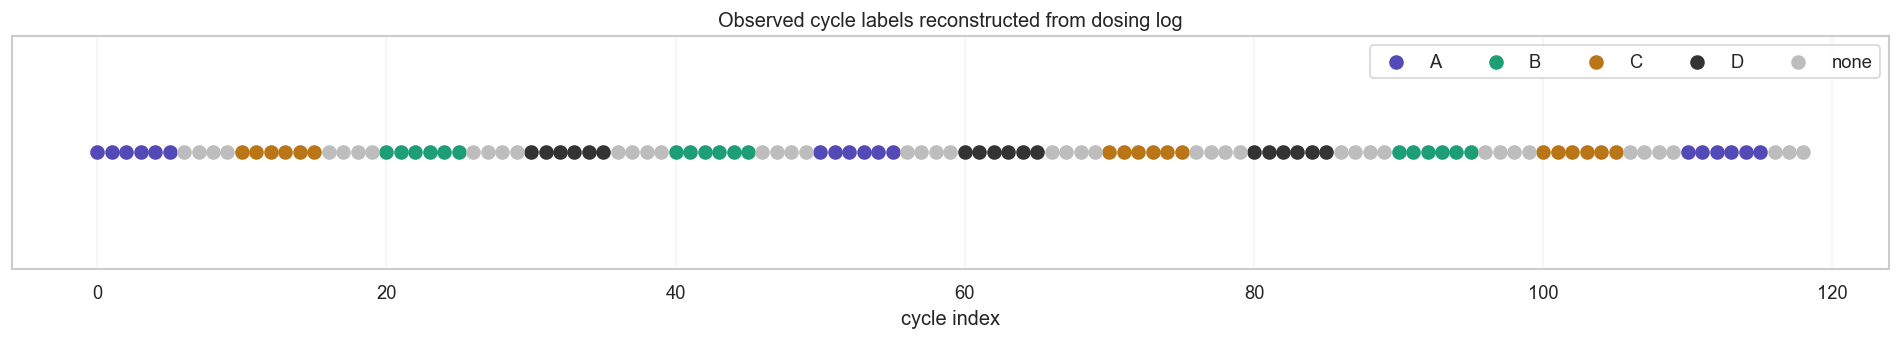

Trials reconstructed:
  Trial  1 | Class A | stimulus cycles found so far: N=18
  Trial  2 | Class C | stimulus cycles found so far: N=18
  Trial  3 | Class B | stimulus cycles found so far: N=18
  Trial  4 | Class D | stimulus cycles found so far: N=18
  Trial  5 | Class B | stimulus cycles found so far: N=18
  Trial  6 | Class A | stimulus cycles found so far: N=18
  Trial  7 | Class D | stimulus cycles found so far: N=18
  Trial  8 | Class C | stimulus cycles found so far: N=18
  Trial  9 | Class D | stimulus cycles found so far: N=18
  Trial 10 | Class B | stimulus cycles found so far: N=18
  Trial 11 | Class C | stimulus cycles found so far: N=18
  Trial 12 | Class A | stimulus cycles found so far: N=18


In [8]:
# Visualize the cycle-level motif class timeline.

fig, ax = plt.subplots(figsize=(16, 3))
color_map = {**CLASS_COLORS, 'none': '#bdbdbd'}
for lab, grp in cycle_df.groupby('motif_class'):
    ax.scatter(grp.index.astype(int), np.ones(len(grp)), s=60,
               label=lab, color=color_map.get(lab, '#333333'))
ax.set_title('Observed cycle labels reconstructed from dosing log')
ax.set_xlabel('cycle index')
ax.set_yticks([])
ax.legend(ncols=5)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUT_DIR / 'cycle_timeline.png', bbox_inches='tight')
plt.show()

# Show trial-level summary
stim_cycles = cycle_df[cycle_df['motif_class'] != 'none']
print('Trials reconstructed:')
for trial_i, cls in enumerate(TRIAL_SEQUENCE):
    n = (stim_cycles['motif_class'] == cls).sum()
    print(f'  Trial {trial_i+1:2d} | Class {cls} | stimulus cycles found so far: N={n}')


### Temporal decoding task

Main task: decode the **motif class (A/B/C/D)** from the 13 sensor channels at each stimulus cycle using delay-embedded reservoir state.

- 4 classes → chance = **25%**
- Good pilot: 45–60% balanced accuracy
- Strong: > 70%

The delay embedding carries sensor history across cycles, letting the readout use the accumulated biological response to the waveform pattern.

In [28]:
# Build the cycle-level classification matrix.
# Each stimulus cycle is one sample; label = motif class of its parent trial.

stim_df = cycle_df.loc[cycle_df['motif_class'].isin(['A','B','C','D'])].copy().sort_index()
X_base  = stim_df[feature_cols].astype(float)
y_base  = stim_df['motif_class'].astype(str).to_numpy()

print('Stimulus cycles :', len(stim_df))
print('Class counts:\n', pd.Series(y_base).value_counts().sort_index().to_string())
print('Feature columns :', feature_cols)
print('NaN per feature:\n', X_base.isna().sum().to_string())

# Forward-fill any NaNs (short sensor dropouts between cycles)
X_base = X_base.ffill().bfill()
print('\nNaN after fill:', X_base.isna().sum().sum())


Stimulus cycles : 72
Class counts:
 A    18
B    18
C    18
D    18
Feature columns : ['OD_45', 'OD_90', 'OD_135', 'norm_od', 'growth_rate', 'nm_415', 'nm_445', 'nm_480', 'nm_515', 'nm_555', 'nm_590', 'nm_630', 'nm_680']
NaN per feature:
 OD_45          0
OD_90          0
OD_135         0
norm_od        0
growth_rate    0
nm_415         0
nm_445         0
nm_480         0
nm_515         0
nm_555         0
nm_590         0
nm_630         0
nm_680         0

NaN after fill: 0


In [29]:

# Helpers for delay embedding and chronological evaluation.

def delay_embed(X: pd.DataFrame | np.ndarray, y: np.ndarray, delay: int):
    X = np.asarray(X, dtype=float)
    if delay < 0:
        raise ValueError("delay must be >= 0")
    if len(X) != len(y):
        raise ValueError("X and y length mismatch")
    if len(X) <= delay:
        raise ValueError("delay is too large for the available samples")

    Xd = []
    yd = []
    for t in range(delay, len(X)):
        Xd.append(np.hstack([X[t - k] for k in range(delay, -1, -1)]))
        yd.append(y[t])
    return np.asarray(Xd, dtype=float), np.asarray(yd)


def chrono_ridge_classifier(X: np.ndarray, y: np.ndarray, delay: int, n_splits: int = 4, alphas=ALPHAS):
    Xd, yd = delay_embed(X, y, delay)
    if len(np.unique(yd)) < 2:
        raise ValueError("Need at least two classes for classification")
    n_splits = max(2, min(n_splits, len(yd) - 1))
    tscv = TimeSeriesSplit(n_splits=n_splits)

    preds = np.empty(len(yd), dtype=object)
    preds[:] = None
    fold_alphas = []
    for train_idx, test_idx in tscv.split(Xd):
        X_train, X_test = Xd[train_idx], Xd[test_idx]
        y_train, y_test = yd[train_idx], yd[test_idx]
        model = make_pipeline(
            StandardScaler(),
            RidgeClassifierCV(alphas=alphas)
        )
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        preds[test_idx] = pred
        clf = model.named_steps["ridgeclassifiercv"]
        fold_alphas.append(float(clf.alpha_))

    mask = preds != None
    y_true = yd[mask]
    y_pred = preds[mask]
    metrics = {
        "delay": delay,
        "n_samples": len(yd),
        "n_tested": int(mask.sum()),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "alpha_median": float(np.median(fold_alphas)),
        "alpha_values": fold_alphas,
        "y_true": y_true,
        "y_pred": y_pred,
        "preds_full": preds,
        "Xd": Xd,
        "yd": yd,
    }
    return metrics


def majority_baseline(y: np.ndarray):
    vals, counts = np.unique(y, return_counts=True)
    return vals[np.argmax(counts)]


def shuffled_null(X: np.ndarray, y: np.ndarray, delay: int, n_perm: int = 200, seed: int = RANDOM_SEED):
    rng = np.random.default_rng(seed)
    stats = []
    for _ in range(n_perm):
        y_perm = rng.permutation(y)
        try:
            m = chrono_ridge_classifier(X, y_perm, delay)
            stats.append(m["balanced_accuracy"])
        except Exception:
            continue
    return np.asarray(stats, dtype=float)


In [30]:

# Sweep delay depths and pick the best one on chronological CV.

X_np = X_base.to_numpy()
y_np = y_base.copy()

results = []
for delay in range(0, min(8, len(y_np) - 1)):
    try:
        m = chrono_ridge_classifier(X_np, y_np, delay=delay, n_splits=5)
        results.append({
            "delay": delay,
            "n_samples": m["n_samples"],
            "n_tested": m["n_tested"],
            "accuracy": m["accuracy"],
            "balanced_accuracy": m["balanced_accuracy"],
            "macro_f1": m["macro_f1"],
            "alpha_median": m["alpha_median"],
        })
    except Exception as e:
        results.append({
            "delay": delay,
            "n_samples": len(y_np),
            "n_tested": np.nan,
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "macro_f1": np.nan,
            "alpha_median": np.nan,
            "error": str(e),
        })

results_df = pd.DataFrame(results)
display(results_df)

best_row = results_df.sort_values(["balanced_accuracy", "macro_f1"], ascending=False).iloc[0]
best_delay = int(best_row["delay"])
print(f"\nBest delay = {best_delay}")


,delay,n_samples,n_tested,accuracy,balanced_accuracy,macro_f1,alpha_median
0,0,72,60,0.050000,0.062500,0.051724,0.100000
1,1,71,55,0.181818,0.183226,0.149896,0.316228
2,2,70,55,0.181818,0.183226,0.149896,0.316228
3,3,69,55,0.163636,0.169338,0.125130,3.162278
4,4,68,55,0.181818,0.190171,0.147654,10.000000
5,5,67,55,0.236364,0.259615,0.188235,100.000000
6,6,66,55,0.254545,0.231838,0.192105,3.162278
7,7,65,50,0.340000,0.336310,0.336014,10.000000



Best delay = 7


Best chronological decoder
delay = 7
tested samples = 52/65
accuracy = 0.288
balanced_accuracy = 0.292
macro_f1 = 0.284
alpha_median = 10.000000

Classification report:

              precision    recall  f1-score   support

           A      0.188     0.250     0.214        12
           B      0.400     0.500     0.444        12
           C      0.222     0.167     0.190        12
           D      0.333     0.250     0.286        16

    accuracy                          0.288        52
   macro avg      0.286     0.292     0.284        52
weighted avg      0.289     0.288     0.284        52



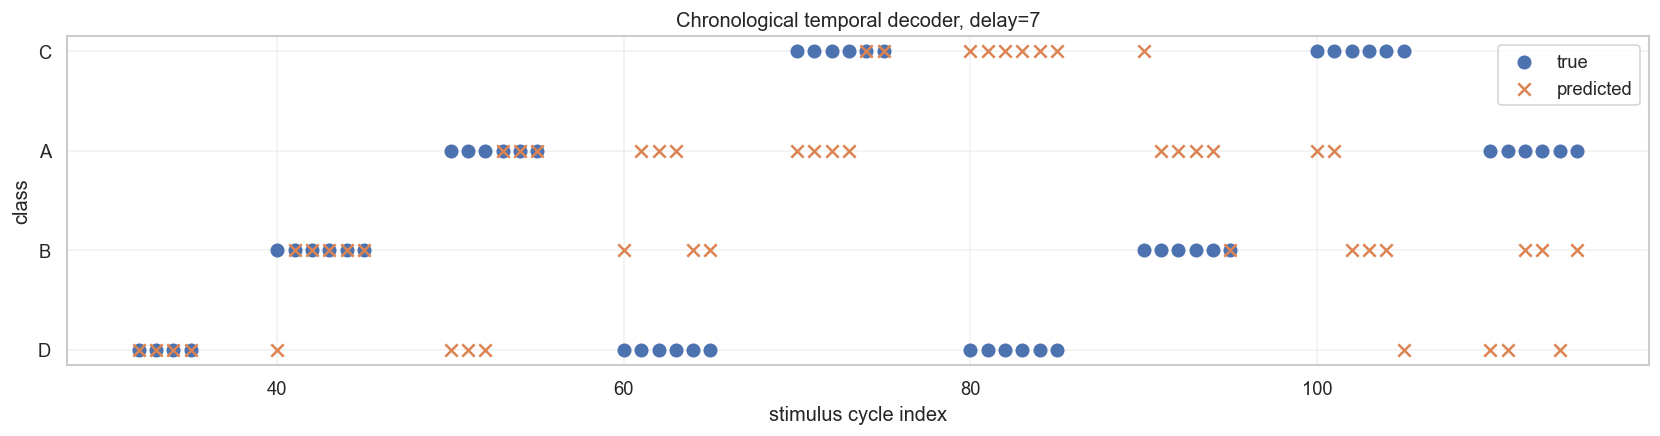

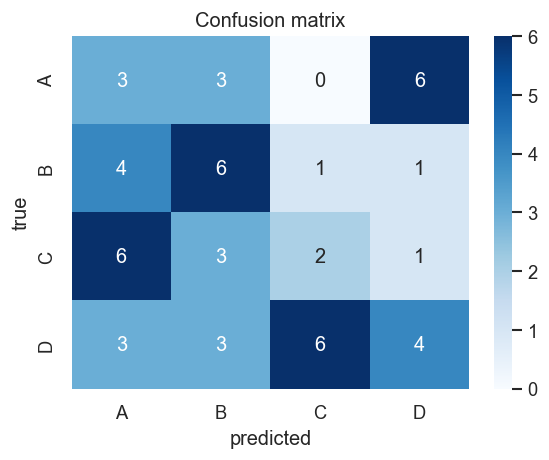

In [31]:

# Fit the best delay model and visualize the chronological predictions.

best_metrics = chrono_ridge_classifier(X_np, y_np, delay=best_delay, n_splits=4)
print("Best chronological decoder")
print(f"delay = {best_delay}")
print(f"tested samples = {best_metrics['n_tested']}/{best_metrics['n_samples']}")
print(f"accuracy = {best_metrics['accuracy']:.3f}")
print(f"balanced_accuracy = {best_metrics['balanced_accuracy']:.3f}")
print(f"macro_f1 = {best_metrics['macro_f1']:.3f}")
print(f"alpha_median = {best_metrics['alpha_median']:.6f}")
print("\nClassification report:\n")
print(classification_report(best_metrics["y_true"], best_metrics["y_pred"], digits=3))

Xd_best, yd_best = delay_embed(X_np, y_np, best_delay)
preds_full = best_metrics["preds_full"]
mask = preds_full != None
plot_idx = stim_df.index.to_numpy()[best_delay:][mask]

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.scatter(plot_idx, yd_best[mask], label="true", s=55, marker="o")
ax.scatter(plot_idx, preds_full[mask], label="predicted", s=55, marker="x")
ax.set_title(f"Chronological temporal decoder, delay={best_delay}")
ax.set_xlabel("stimulus cycle index")
ax.set_ylabel("class")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(best_metrics["y_true"], best_metrics["y_pred"], labels=np.unique(y_np))
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_np), yticklabels=np.unique(y_np), ax=ax)
ax.set_title("Confusion matrix")
ax.set_xlabel("predicted")
ax.set_ylabel("true")
plt.tight_layout()
plt.show()


LSTM input  : (65, 8, 13)  (samples × timesteps × features)
Classes     : ['A' 'B' 'C' 'D']  — chance = 25%
  Fold 1: balanced_accuracy = 0.333  (n_train=15, n_test=10)
  Fold 2: balanced_accuracy = 0.500  (n_train=25, n_test=10)
  Fold 3: balanced_accuracy = 0.500  (n_train=35, n_test=10)
  Fold 4: balanced_accuracy = 0.500  (n_train=45, n_test=10)
  Fold 5: balanced_accuracy = 0.500  (n_train=55, n_test=10)

LSTM  balanced accuracy : 0.467 ± 0.067
Ridge balanced accuracy : 0.292
Chance                  : 0.250


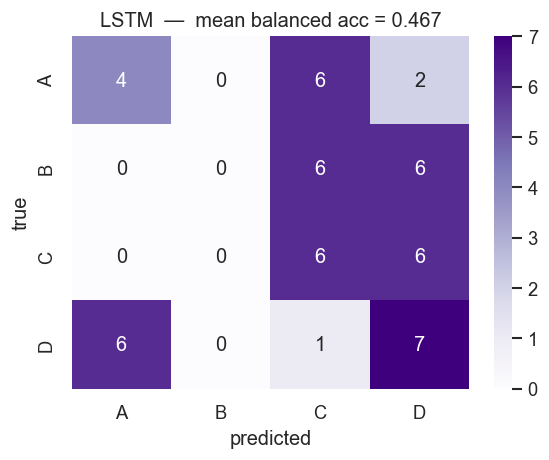

In [ ]:
# ── LSTM Reservoir Readout ─────────────────────────────────────────────

import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
import numpy as np

# ── Build 3D sequences (samples × timesteps × features) ───────────────
# Reuses best_delay already found by the Ridge sweep
SEQ_LEN    = best_delay + 1
N_FEATURES = X_np.shape[1]

def build_sequences(X, y_labels, seq_len):
    X3d, y_out = [], []
    for t in range(seq_len - 1, len(X)):
        X3d.append(X[t - seq_len + 1 : t + 1])  # (seq_len, n_features)
        y_out.append(y_labels[t])
    return np.array(X3d, dtype=np.float32), np.array(y_out)

le      = LabelEncoder()
y_enc   = le.fit_transform(y_np)          # A→0, B→1, C→2, D→3
X3d, y3d = build_sequences(X_np, y_enc, SEQ_LEN)

print(f"LSTM input  : {X3d.shape}  (samples × timesteps × features)")
print(f"Classes     : {le.classes_}  — chance = 25%")

# ── Model factory ──────────────────────────────────────────────────────
def build_lstm(seq_len, n_features, n_classes):
    model = keras.Sequential([
        keras.layers.Input(shape=(seq_len, n_features)),
        keras.layers.LSTM(32, return_sequences=False),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(n_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

# ── Chronological CV (same split as Ridge) ─────────────────────────────
tscv_lstm               = TimeSeriesSplit(n_splits=5)
lstm_bal_accs           = []
lstm_all_true, lstm_all_pred = [], []

for fold, (tr, te) in enumerate(tscv_lstm.split(X3d)):
    X_tr, X_te = X3d[tr], X3d[te]
    y_tr, y_te = y3d[tr], y3d[te]

    # Re-scale per fold to avoid leakage
    sc   = StandardScaler()
    n, t, f = X_tr.shape
    X_tr = sc.fit_transform(X_tr.reshape(-1, f)).reshape(n, t, f)
    n2   = X_te.shape[0]
    X_te = sc.transform(X_te.reshape(-1, f)).reshape(n2, t, f)

    model = build_lstm(SEQ_LEN, f, len(le.classes_))
    model.fit(
        X_tr, y_tr,
        epochs         = 100,
        batch_size     = max(4, len(X_tr) // 4),
        verbose        = 0,
        validation_data= (X_te, y_te),
    )

    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
    ba     = balanced_accuracy_score(y_te, y_pred)
    lstm_bal_accs.append(ba)
    lstm_all_true.extend(y_te)
    lstm_all_pred.extend(y_pred)
    print(f"  Fold {fold+1}: balanced_accuracy = {ba:.3f}  (n_train={len(X_tr)}, n_test={len(X_te)})")

lstm_mean = np.mean(lstm_bal_accs)
print(f"\nLSTM  balanced accuracy : {lstm_mean:.3f} ± {np.std(lstm_bal_accs):.3f}")
print(f"Ridge balanced accuracy : {best_metrics['balanced_accuracy']:.3f}")
print(f"Chance                  : 0.250")

# ── Confusion matrix ───────────────────────────────────────────────────
cm = confusion_matrix(lstm_all_true, lstm_all_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'LSTM  —  mean balanced acc = {lstm_mean:.3f}')
ax.set_xlabel('predicted')
ax.set_ylabel('true')
plt.tight_layout()
plt.savefig(OUT_DIR / 'lstm_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [18]:
fold_boundaries = list(tscv_lstm.split(X3d))
_, test_idx_fold4 = fold_boundaries[3]
print("Fold 4 test classes:", le.inverse_transform(y3d[test_idx_fold4]))

Fold 4 test classes: ['D' 'D' 'B' 'B' 'B' 'B' 'B' 'B' 'C' 'C']


In [ ]:
Train on folds 1-3, test fold 4 and fold 5 separately ─────

fold_boundaries = list(tscv_lstm.split(X3d))

# Build train index from folds 1-3
tr_1to3 = fold_boundaries[2][0]   # fold 3's train_idx already includes folds 1+2+3
_, te4   = fold_boundaries[3]
_, te5   = fold_boundaries[4]

X_tr = X3d[tr_1to3]
y_tr = y3d[tr_1to3]

# Re-scale on training data only
sc2  = StandardScaler()
n, t, f = X_tr.shape
X_tr = sc2.fit_transform(X_tr.reshape(-1, f)).reshape(n, t, f)

X_te4 = sc2.transform(X3d[te4].reshape(-1, f)).reshape(len(te4), t, f)
X_te5 = sc2.transform(X3d[te5].reshape(-1, f)).reshape(len(te5), t, f)

# Train once
model_step2 = build_lstm(SEQ_LEN, f, len(le.classes_))
model_step2.fit(X_tr, y_tr, epochs=100,
                batch_size=max(4, len(X_tr)//4), verbose=0)

# Test on fold 4 and fold 5 separately
pred4 = np.argmax(model_step2.predict(X_te4, verbose=0), axis=1)
pred5 = np.argmax(model_step2.predict(X_te5, verbose=0), axis=1)

ba4 = balanced_accuracy_score(y3d[te4], pred4)
ba5 = balanced_accuracy_score(y3d[te5], pred5)

print(f"Train on folds 1-3  (n={len(X_tr)})")
print(f"Test  fold 4        (n={len(te4)}) → balanced_accuracy = {ba4:.3f}")
print(f"Test  fold 5        (n={len(te5)}) → balanced_accuracy = {ba5:.3f}")
print()
print(f"Fold 4 true  : {le.inverse_transform(y3d[te4])}")
print(f"Fold 4 pred  : {le.inverse_transform(pred4)}")
print()
print(f"Fold 5 true  : {le.inverse_transform(y3d[te5])}")
print(f"Fold 5 pred  : {le.inverse_transform(pred5)}")

Train on folds 1-3  (n=35)
Test  fold 4        (n=10) → balanced_accuracy = 0.667
Test  fold 5        (n=10) → balanced_accuracy = 0.500

Fold 4 true  : ['D' 'D' 'B' 'B' 'B' 'B' 'B' 'B' 'C' 'C']
Fold 4 pred  : ['D' 'D' 'D' 'D' 'C' 'C' 'C' 'C' 'C' 'C']

Fold 5 true  : ['C' 'C' 'C' 'C' 'A' 'A' 'A' 'A' 'A' 'A']
Fold 5 pred  : ['C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C']


Detrended input shape : (65, 8, 13)
  Fold 1: balanced_accuracy = 0.500  | test classes: ['D' 'D' 'B' 'B' 'B' 'B' 'B' 'B' 'A' 'A']


c:\Program Files\python\lib\site-packages\sklearn\metrics\_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  Fold 2: balanced_accuracy = 0.000  | test classes: ['A' 'A' 'A' 'A' 'D' 'D' 'D' 'D' 'D' 'D']


c:\Program Files\python\lib\site-packages\sklearn\metrics\_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  Fold 3: balanced_accuracy = 0.000  | test classes: ['C' 'C' 'C' 'C' 'C' 'C' 'D' 'D' 'D' 'D']
  Fold 4: balanced_accuracy = 0.333  | test classes: ['D' 'D' 'B' 'B' 'B' 'B' 'B' 'B' 'C' 'C']


c:\Program Files\python\lib\site-packages\sklearn\metrics\_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  Fold 5: balanced_accuracy = 0.250  | test classes: ['C' 'C' 'C' 'C' 'A' 'A' 'A' 'A' 'A' 'A']

Detrended LSTM  : 0.217 ± 0.194
Original LSTM   : 0.433 ± 0.082
Ridge           : 0.292
Chance          : 0.250


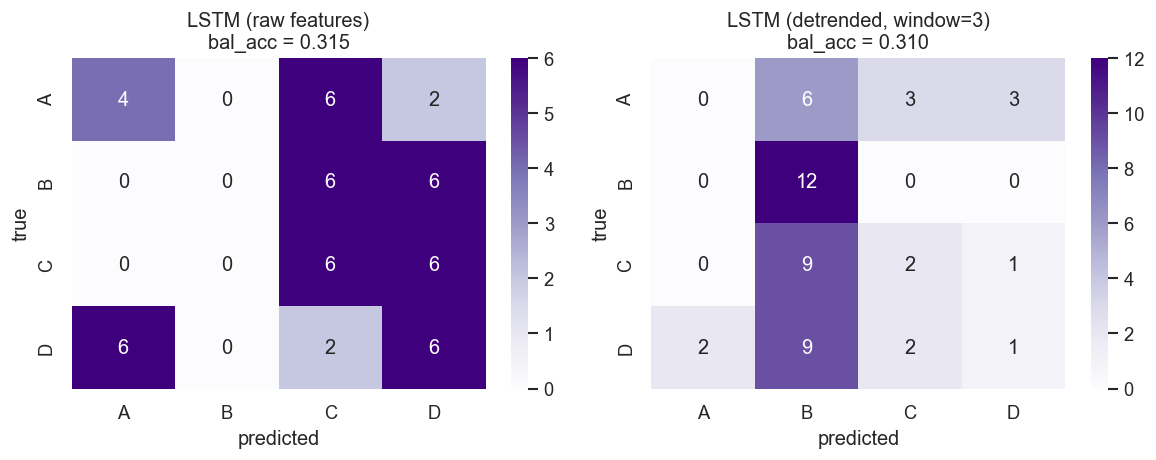

In [21]:
# ── Non-stationarity correction — rolling baseline subtraction ─────────
# For each cycle t, subtract the mean of the previous `baseline_window`
# cycles. Removes slow culture drift, makes early and late cycles comparable.

BASELINE_WINDOW = 3   # how many previous cycles to use as local baseline

def rolling_baseline_subtract(X: np.ndarray, window: int) -> np.ndarray:
    X_out = np.zeros_like(X)
    for t in range(len(X)):
        if t == 0:
            # No history — subtract nothing (zero-centre on itself)
            X_out[t] = X[t] - X[t]
        else:
            # Use up to `window` cycles strictly before t
            start     = max(0, t - window)
            baseline  = X[start:t].mean(axis=0)
            X_out[t]  = X[t] - baseline
    return X_out

# Apply to raw X_np before building sequences
X_detrended      = rolling_baseline_subtract(X_np, BASELINE_WINDOW)
X3d_dt, y3d_dt   = build_sequences(X_detrended, y_enc, SEQ_LEN)

print(f"Detrended input shape : {X3d_dt.shape}")

# ── Re-run chronological CV with detrended features ───────────────────
tscv_dt                   = TimeSeriesSplit(n_splits=5)
dt_bal_accs               = []
dt_all_true, dt_all_pred  = [], []

for fold, (tr, te) in enumerate(tscv_dt.split(X3d_dt)):
    X_tr, X_te = X3d_dt[tr], X3d_dt[te]
    y_tr, y_te = y3d_dt[tr], y3d_dt[te]

    sc   = StandardScaler()
    n, t, f = X_tr.shape
    X_tr = sc.fit_transform(X_tr.reshape(-1, f)).reshape(n, t, f)
    X_te = sc.transform(X_te.reshape(-1, f)).reshape(len(te), t, f)

    model_dt = build_lstm(SEQ_LEN, f, len(le.classes_))
    model_dt.fit(X_tr, y_tr,
                 epochs=100,
                 batch_size=max(4, len(X_tr)//4),
                 verbose=0,
                 validation_data=(X_te, y_te))

    y_pred = np.argmax(model_dt.predict(X_te, verbose=0), axis=1)
    ba     = balanced_accuracy_score(y_te, y_pred)
    dt_bal_accs.append(ba)
    dt_all_true.extend(y_te)
    dt_all_pred.extend(y_pred)
    print(f"  Fold {fold+1}: balanced_accuracy = {ba:.3f}  "
          f"| test classes: {le.inverse_transform(y3d_dt[te])}")

dt_mean = np.mean(dt_bal_accs)
print(f"\nDetrended LSTM  : {dt_mean:.3f} ± {np.std(dt_bal_accs):.3f}")
print(f"Original LSTM   : {np.mean(lstm_bal_accs):.3f} ± {np.std(lstm_bal_accs):.3f}")
print(f"Ridge           : {best_metrics['balanced_accuracy']:.3f}")
print(f"Chance          : 0.250")

# ── Side-by-side confusion matrices ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, true, pred, title in zip(
    axes,
    [lstm_all_true, dt_all_true],
    [lstm_all_pred, dt_all_pred],
    ['LSTM (raw features)', f'LSTM (detrended, window={BASELINE_WINDOW})'],
):
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(f'{title}\nbal_acc = {balanced_accuracy_score(true, pred):.3f}')
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
plt.tight_layout()
plt.savefig(OUT_DIR / 'lstm_detrended_comparison.png', bbox_inches='tight')
plt.show()

  Fold 1: balanced_accuracy = 0.333  | test classes: ['D' 'D' 'B' 'B' 'B' 'B' 'B' 'B' 'A' 'A']


c:\Program Files\python\lib\site-packages\sklearn\metrics\_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  Fold 2: balanced_accuracy = 0.375  | test classes: ['A' 'A' 'A' 'A' 'D' 'D' 'D' 'D' 'D' 'D']
  Fold 3: balanced_accuracy = 0.500  | test classes: ['C' 'C' 'C' 'C' 'C' 'C' 'D' 'D' 'D' 'D']
  Fold 4: balanced_accuracy = 0.333  | test classes: ['D' 'D' 'B' 'B' 'B' 'B' 'B' 'B' 'C' 'C']
  Fold 5: balanced_accuracy = 0.500  | test classes: ['C' 'C' 'C' 'C' 'A' 'A' 'A' 'A' 'A' 'A']

GRU   : 0.408 ± 0.076
LSTM  : 0.433 ± 0.082
Ridge : 0.292
Chance: 0.250


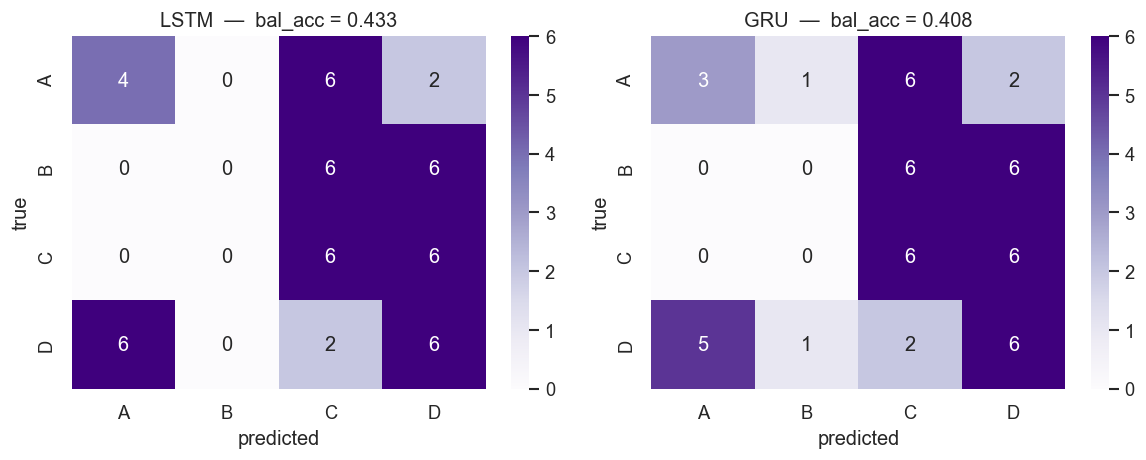

In [ ]:
# ── GRU Reservoir Readout ──────────────────────────────────────────────

def build_gru(seq_len, n_features, n_classes):
    model = keras.Sequential([
        keras.layers.Input(shape=(seq_len, n_features)),
        keras.layers.GRU(32, return_sequences=False),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(n_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

# ── Chronological CV ───────────────────────────────────────────────────
tscv_gru                    = TimeSeriesSplit(n_splits=5)
gru_bal_accs                = []
gru_all_true, gru_all_pred  = [], []

for fold, (tr, te) in enumerate(tscv_gru.split(X3d)):
    X_tr, X_te = X3d[tr], X3d[te]
    y_tr, y_te = y3d[tr], y3d[te]

    sc = StandardScaler()
    n, t, f = X_tr.shape
    X_tr = sc.fit_transform(X_tr.reshape(-1, f)).reshape(n, t, f)
    X_te = sc.transform(X_te.reshape(-1, f)).reshape(len(te), t, f)

    model_gru = build_gru(SEQ_LEN, f, len(le.classes_))
    model_gru.fit(
        X_tr, y_tr,
        epochs          = 100,
        batch_size      = max(4, len(X_tr)//4),
        verbose         = 0,
        validation_data = (X_te, y_te),
    )

    y_pred = np.argmax(model_gru.predict(X_te, verbose=0), axis=1)
    ba     = balanced_accuracy_score(y_te, y_pred)
    gru_bal_accs.append(ba)
    gru_all_true.extend(y_te)
    gru_all_pred.extend(y_pred)
    print(f"  Fold {fold+1}: balanced_accuracy = {ba:.3f}  "
          f"| test classes: {le.inverse_transform(y3d[te])}")

gru_mean = np.mean(gru_bal_accs)
print(f"\nGRU   : {gru_mean:.3f} ± {np.std(gru_bal_accs):.3f}")
print(f"LSTM  : {np.mean(lstm_bal_accs):.3f} ± {np.std(lstm_bal_accs):.3f}")
print(f"Ridge : {best_metrics['balanced_accuracy']:.3f}")
print(f"Chance: 0.250")

# ── Confusion matrix ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, true, pred, title, mean in zip(
    axes,
    [lstm_all_true,  gru_all_true],
    [lstm_all_pred,  gru_all_pred],
    ['LSTM',         'GRU'],
    [np.mean(lstm_bal_accs), gru_mean],
):
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(f'{title}  —  bal_acc = {mean:.3f}')
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
plt.tight_layout()
plt.savefig(OUT_DIR / 'gru_vs_lstm.png', bbox_inches='tight')
plt.show()

In [33]:
# ── LSTM as feature extractor → Ridge readout ─────────────────────────

# 1. Build LSTM that outputs hidden state instead of class probabilities
def build_lstm_encoder(seq_len, n_features, units=32):
    model = keras.Sequential([
        keras.layers.Input(shape=(seq_len, n_features)),
        keras.layers.LSTM(units, return_sequences=False),  # outputs (batch, 32)
        # no Dense head — we want the raw hidden state
    ])
    return model

tscv_hybrid                       = TimeSeriesSplit(n_splits=5)
hybrid_bal_accs                   = []
hybrid_all_true, hybrid_all_pred  = [], []

for fold, (tr, te) in enumerate(tscv_hybrid.split(X3d)):
    X_tr, X_te = X3d[tr], X3d[te]
    y_tr, y_te = y3d[tr], y3d[te]

    # Scale input
    sc = StandardScaler()
    n, t, f = X_tr.shape
    X_tr_sc = sc.fit_transform(X_tr.reshape(-1, f)).reshape(n, t, f)
    X_te_sc = sc.transform(X_te.reshape(-1, f)).reshape(len(te), t, f)

    # 2. Train LSTM encoder with a temporary classification head
    encoder_input  = keras.Input(shape=(SEQ_LEN, f))
    lstm_out       = keras.layers.LSTM(32, return_sequences=False)(encoder_input)
    dropped        = keras.layers.Dropout(0.2)(lstm_out)
    class_out      = keras.layers.Dense(len(le.classes_), activation='softmax')(dropped)
    full_model     = keras.Model(encoder_input, class_out)
    full_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                       loss='sparse_categorical_crossentropy')
    full_model.fit(X_tr_sc, y_tr, epochs=100,
                   batch_size=max(4, len(X_tr)//4), verbose=0)

    # 3. Extract hidden state (strip classification head)
    encoder        = keras.Model(encoder_input, lstm_out)
    X_tr_encoded   = encoder.predict(X_tr_sc, verbose=0)  # shape: (n_train, 32)
    X_te_encoded   = encoder.predict(X_te_sc, verbose=0)  # shape: (n_test,  32)

    # 4. Ridge on top of LSTM hidden state
    ridge          = make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=ALPHAS))
    ridge.fit(X_tr_encoded, y_tr)
    y_pred         = ridge.predict(X_te_encoded)

    ba = balanced_accuracy_score(y_te, y_pred)
    hybrid_bal_accs.append(ba)
    hybrid_all_true.extend(y_te)
    hybrid_all_pred.extend(y_pred)
    print(f"  Fold {fold+1}: balanced_accuracy = {ba:.3f}  "
          f"| test classes: {le.inverse_transform(y3d[te])}")

hybrid_mean = np.mean(hybrid_bal_accs)
print(f"\nLSTM → Ridge (hybrid) : {hybrid_mean:.3f} ± {np.std(hybrid_bal_accs):.3f}")
print(f"LSTM end-to-end       : {np.mean(lstm_bal_accs):.3f} ± {np.std(lstm_bal_accs):.3f}")
print(f"Ridge (raw features)  : {best_metrics['balanced_accuracy']:.3f}")
print(f"Chance                : 0.250")

  Fold 1: balanced_accuracy = 0.333  | test classes: ['D' 'D' 'B' 'B' 'B' 'B' 'B' 'B' 'A' 'A']
  Fold 2: balanced_accuracy = 0.500  | test classes: ['A' 'A' 'A' 'A' 'D' 'D' 'D' 'D' 'D' 'D']
  Fold 3: balanced_accuracy = 0.500  | test classes: ['C' 'C' 'C' 'C' 'C' 'C' 'D' 'D' 'D' 'D']
  Fold 4: balanced_accuracy = 0.333  | test classes: ['D' 'D' 'B' 'B' 'B' 'B' 'B' 'B' 'C' 'C']
  Fold 5: balanced_accuracy = 0.500  | test classes: ['C' 'C' 'C' 'C' 'A' 'A' 'A' 'A' 'A' 'A']

LSTM → Ridge (hybrid) : 0.433 ± 0.082
LSTM end-to-end       : 0.467 ± 0.067
Ridge (raw features)  : 0.292
Chance                : 0.250


### Trial-level summary

to check decoded accuracy broken down per trial (each trial = 6 cycles).
A well-functioning decoder should be more accurate within later cycles of a trial
as accumulated biological state carries more information about the waveform pattern.

In [15]:
# Trial-level accuracy: for each trial, majority-vote the per-cycle predictions.

X_np = X_base.to_numpy()
y_np = y_base.copy()

from sklearn.base import clone

# Re-fit on all data to get trial-level insight (not a held-out score)
pipe_all = make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=ALPHAS))
pipe_all.fit(X_np, y_np)
y_pred_all = pipe_all.predict(X_np)

stim_df_copy = stim_df.copy()
stim_df_copy['pred_class'] = y_pred_all

# Assign trial index to each cycle
cycle_bursts_full = (
    media_ev.groupby('burst_group')
    .agg(cycle_idx=('cycle_idx', 'first'))
    .reset_index(drop=True)
)
cycle_bursts_full['trial_idx'] = cycle_bursts_full.index // STIMULUS_CYCLES
cycle_to_trial = cycle_bursts_full.set_index('cycle_idx')['trial_idx']
stim_df_copy['trial_idx'] = stim_df_copy.index.map(cycle_to_trial)

trial_summary = (
    stim_df_copy.groupby('trial_idx')
    .apply(lambda g: pd.Series({
        'true_class' : g['motif_class'].iloc[0],
        'voted_pred' : pd.Series(g['pred_class']).mode()[0],
        'n_cycles'   : len(g),
    }))
    .reset_index()
)
trial_summary['correct'] = trial_summary['true_class'] == trial_summary['voted_pred']
print('Trial-level majority-vote accuracy (train set — not held-out):')
print(trial_summary[['trial_idx','true_class','voted_pred','correct']].to_string(index=False))
print(f"\nTrial accuracy: {trial_summary['correct'].mean():.2f}")


Trial-level majority-vote accuracy (train set — not held-out):
 trial_idx true_class voted_pred  correct
         0          A          A     True
         1          C          C     True
         2          B          B     True
         3          D          D     True
         4          B          B     True
         5          A          D    False
         6          D          D     True
         7          C          D    False
         8          D          D     True
         9          B          C    False
        10          C          A    False
        11          A          A     True

Trial accuracy: 0.67


### Verification controls

Two controls that must hold for the result to be meaningful:
1. **Rolled labels** — shift labels by 1 position; accuracy should drop toward 25%
2. **Shuffled null** — permute labels 200 times; real balanced accuracy must sit clearly above the null distribution

Chance level for 4 classes = **25%**.

Rolled-label control
delay = 7, roll = 1
balanced_accuracy = 0.300
macro_f1 = 0.257

Shuffled null: median=0.213, min=0.083, max=0.356
Empirical p-value (balanced accuracy >= real): 0.0448


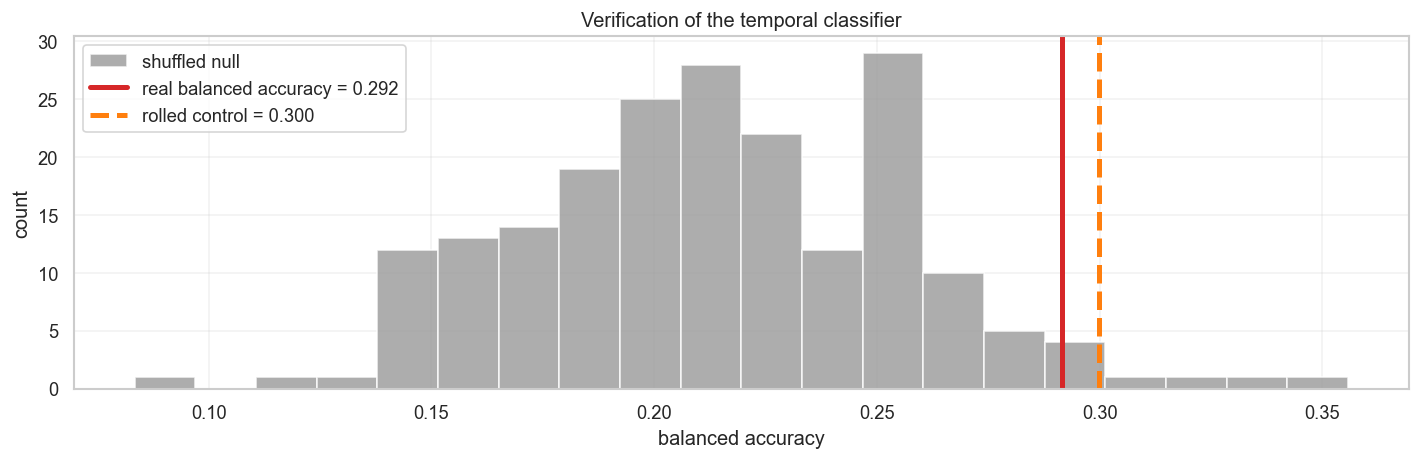

In [14]:

# Verification: rolled labels and shuffled null.

# Rolled labels control.
roll = 1
y_roll = np.roll(y_np, roll)
roll_metrics = chrono_ridge_classifier(X_np, y_roll, delay=best_delay, n_splits=4)
print("Rolled-label control")
print(f"delay = {best_delay}, roll = {roll}")
print(f"balanced_accuracy = {roll_metrics['balanced_accuracy']:.3f}")
print(f"macro_f1 = {roll_metrics['macro_f1']:.3f}")

# Shuffle null.
null_stats = shuffled_null(X_np, y_np, delay=best_delay, n_perm=200)
real_score = best_metrics["balanced_accuracy"]
p_value = (1 + np.sum(null_stats >= real_score)) / (1 + len(null_stats)) if len(null_stats) else np.nan
print(f"\nShuffled null: median={np.median(null_stats):.3f}, min={np.min(null_stats):.3f}, max={np.max(null_stats):.3f}")
print(f"Empirical p-value (balanced accuracy >= real): {p_value:.4f}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(null_stats, bins=20, color="#999999", alpha=0.8, label="shuffled null")
ax.axvline(real_score, color="#d62728", linewidth=3, label=f"real balanced accuracy = {real_score:.3f}")
ax.axvline(roll_metrics["balanced_accuracy"], color="#ff7f0e", linewidth=3, linestyle="--", label=f"rolled control = {roll_metrics['balanced_accuracy']:.3f}")
ax.set_title("Verification of the temporal classifier")
ax.set_xlabel("balanced accuracy")
ax.set_ylabel("count")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
